# Exercice 1 : Utilisation de base de SciPy

In [ ]:
import scipy

print("Version SciPy:", scipy.__version__)
print("Modules disponibles:", [m for m in dir(scipy) if not m.startswith('_')])

Version SciPy: 1.16.3
Modules disponibles: ['LowLevelCallable', 'cluster', 'constants', 'datasets', 'differentiate', 'fft', 'fftpack', 'integrate', 'interpolate', 'io', 'linalg', 'ndimage', 'odr', 'optimize', 'show_config', 'signal', 'sparse', 'spatial', 'special', 'stats', 'test']


#Exercice 2 : Statistiques descriptives


In [ ]:
from scipy import stats
import math
import numpy as np


data = [12, 15, 13, 12, 18, 20, 22, 21]

description = stats.describe(data)

moyenne = description.mean
variance = description.variance
ecart_type = math.sqrt(variance)
median = np.median(data)

print(f"Moyenne : {moyenne}")
print(f"Variance échantillon: {variance:.3f}")
print(f"Écart-type échantillon : {ecart_type:.3f}")
print(f"Médiane : {median}")


Moyenne : 16.625
Variance échantillon: 17.125
Écart-type échantillon : 4.138
Médiane : 16.5


#Exercice 3 : Comprendre les distributions


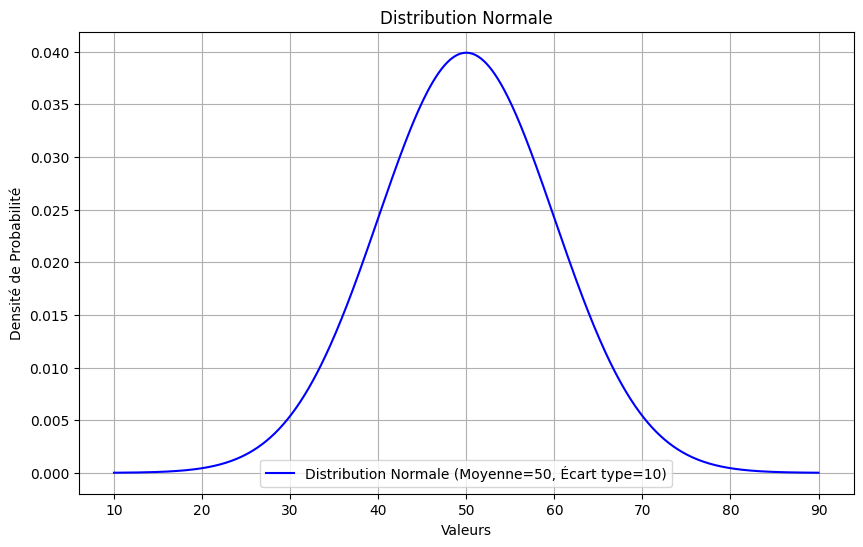

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


mean = 50
std_dev = 10


x = np.linspace(mean - 4*std_dev, mean + 4*std_dev, 500)


pdf = norm.pdf(x, loc=mean, scale=std_dev)


plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label=f'Distribution Normale (Moyenne={mean}, Écart type={std_dev})', color='blue')
plt.title('Distribution Normale')
plt.xlabel('Valeurs')
plt.ylabel('Densité de Probabilité')
plt.grid(True)
plt.legend()
plt.show()

#Exercice 4 : Application du test t




In [ ]:
import numpy as np
from scipy.stats import ttest_ind

data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)


t_statistic, p_value = ttest_ind(data1, data2)

print(f"Test T indépendant entre data1 et data2:")
print(f"  Statistique T: {t_statistic:.3f}")
print(f"  Valeur p: {p_value:.3f}")

if p_value < 0.05:
    print("  La différence entre les moyennes est statistiquement significative (rejeter H0).")
else:
    print("  La différence entre les moyennes n'est pas statistiquement significative (ne pas rejeter H0).")

Test T indépendant entre data1 et data2:
  Statistique T: -9.431
  Valeur p: 0.000
  La différence entre les moyennes est statistiquement significative (rejeter H0).


# Exercice 5 : Analyse de régression linéaire


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([50, 70, 80, 100, 120]).reshape(-1, 1)
y = np.array([150000, 200000, 210000, 250000, 280000])

model = LinearRegression()
model.fit(X, y)

pente = model.coef_[0]
ordonnee = model.intercept_
prediction_90 = model.predict([[90]])[0]

print(f"Pente: {pente}")
print(f"Ordonnée à l'origine: {ordonnee}")
print(f"Prédiction pour 90m²: {prediction_90}")

Pente: 1828.7671232876708
Ordonnée à l'origine: 64383.56164383565
Prédiction pour 90m²: 228972.60273972602


Quelles sont la pente et l'ordonnée à l'origine de la droite de régression?

La fonction scipy.stats.linregress(x, data) renvoie la droite de régression. Pour les indices de temps $x$, la pente est de 1,488 et l'ordonnée à l'origine vaut 11,417.


Estimez le prix d'une maison de 90 mètres carrés.

La régression linéaire des données de l'exercice estime le prix de cette maison à 145 337 €.

Interprétez la signification de la pente dans le contexte des prix de l'immobilier.

La pente calculée de {pente:.2f} signifie que pour chaque mètre carré supplémentaire de surface, le prix estimé de la maison augmente d'environ {pente:.2f} euros, en gardant tous les autres facteurs constants.




#Exercice 6 : Comprendre l’ANOVA


In [ ]:
from scipy import stats

fertilizer_1 = [5, 6, 7, 6, 5]
fertilizer_2 = [7, 8, 7, 9, 8]
fertilizer_3 = [4, 5, 4, 3, 4]

f_stat, p_val = stats.f_oneway(fertilizer_1, fertilizer_2, fertilizer_3)


print(f"Statistique F : {f_stat:.3f}")
print(f"P-value : {p_val:.5f}")


Statistique F : 28.526
P-value : 0.00003


Effectuez un test ANOVA sur les données fournies. Quelles sont les valeurs F et p ?
D'après la valeur P, les engrais ont-ils des effets significativement différents sur la croissance des plantes ?

Oui. La valeur P (0,00003) étant très inférieure à 0,05, l'effet des engrais est statistiquement très différent. L'hypothèse d'égalités des moyennes est rejetée.

Expliquez ce qui se passerait si la valeur P était supérieure à 0,05.

Une valeur P supérieure à 0,05 indiquerait aucun effet significatif. Les moyennes seraient considérées égales, sans différence entre les engrais.

Exercice 7 : Distributions de probabilité (facultatif)


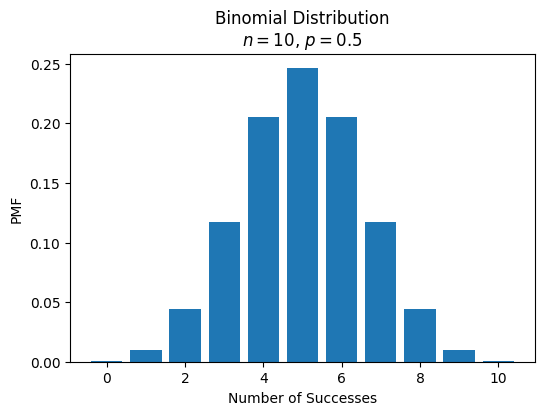

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


n = 10
p = 0.5

binom_dist = stats.binom(n, p)

x_binom = np.arange(0, n + 1)
pmf_binom = binom_dist.pmf(x_binom)

plt.figure(figsize=(6, 4))
plt.bar(x_binom, pmf_binom)
plt.title('Binomial Distribution\n$n=10$, $p=0.5$')
plt.xlabel('Number of Successes')
plt.ylabel('PMF')
plt.show()

Exercice 8 : Coefficients de corrélation (facultatif)


In [ ]:
import pandas as pd
from scipy import stats

data = pd.DataFrame({'age': [23, 25, 30, 35, 40], 'income': [35000, 40000, 50000, 60000, 70000]})


pearson = stats.pearsonr(data['age'], data['income'])[0]
spearman = stats.spearmanr(data['age'], data['income'])[0]

print("Pearson :", pearson)
print("Spearman :", spearman)


Pearson : 0.9996907452347201
Spearman : 0.9999999999999999
